In [1]:
# 加载数据
import torch
from joblib import dump, load
import torch.utils.data as Data
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
# 参数与配置
torch.manual_seed(100)  # 设置随机种子，以使实验结果具有可重复性
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 加载数据集
def dataloader(batch_size, workers=2):
    # 训练集
    train_set = load('../dataresult/train_set')
    train_label = load('../dataresult/train_label')
    # 测试集
    test_set = load('../dataresult/test_set')
    test_label = load('../dataresult/test_label')

    # 加载数据
    train_loader = Data.DataLoader(dataset=Data.TensorDataset(train_set, train_label),
                                   batch_size=batch_size, num_workers=workers, drop_last=True)
    test_loader = Data.DataLoader(dataset=Data.TensorDataset(test_set, test_label),
                                  batch_size=batch_size, num_workers=workers, drop_last=True)
    return train_loader, test_loader

batch_size = 32
# 加载数据
train_loader, test_loader = dataloader(batch_size)

print(len(train_loader))
print(len(test_loader))

114
73


In [2]:
# 定义裁剪模块
class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super(Chomp1d, self).__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous()

#  定义 TCN 卷积+残差 模块
from torch.nn.utils import parametrizations

class TemporalBlock(nn.Module):
    def __init__(self, n_inputs, n_outputs, kernel_size, stride, dilation, padding, dropout=0.5):
        super(TemporalBlock, self).__init__()
        """
        params: 构成TCN的核心Block, 原作者在图中成为Residual block, 是因为它存在残差连接.
        但注意, 这个模块包含了2个Conv1d.

        n_inputs         : 输入通道数或者特征数
        n_outputs        : 输出通道数或者特征数
        kernel_size      : 卷积核大小
        stride           : 步长, 在TCN固定为1
        dilation         : 膨胀系数. 与这个Residual block(或者说, 隐藏层)所在的层数有关系. 
                            例如, 如果这个Residual block在第1层, dilation = 2**0 = 1;
                                    如果这个Residual block在第2层, dilation = 2**1 = 2;
                                    如果这个Residual block在第3层, dilation = 2**2 = 4;
                                    如果这个Residual block在第4层, dilation = 2**3 = 8 ......
        padding          : 填充系数. 与kernel_size和dilation有关
        dropout          : drop_out比率
        """
        # 第一层 卷积
        self.conv1 = parametrizations.weight_norm(nn.Conv1d(n_inputs, n_outputs, kernel_size,
                                           stride=stride, padding=padding, dilation=dilation))
        # 因为 padding 的时候, 在序列的左边和右边都有填充, 所以要裁剪
        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        # 第二层 卷积
        self.conv2 =parametrizations.weight_norm(nn.Conv1d(n_outputs, n_outputs, kernel_size,
                                           stride=stride, padding=padding, dilation=dilation))
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.net = nn.Sequential(self.conv1, self.chomp1, self.relu1, self.dropout1,
                                 self.conv2, self.chomp2, self.relu2, self.dropout2)

        # 1×1的卷积. 只有在进入Residual block的通道数与出Residual block的通道数不一样时使用.
        # 一般都会不一样, 除非num_channels这个里面的数, 与num_inputs相等. 例如[5,5,5], 并且num_inputs也是5
        self.downsample = nn.Conv1d(n_inputs, n_outputs, 1) if n_inputs != n_outputs else None  # 进行下采样

        # 在整个Residual block中有非线性的激活
        self.relu = nn.ReLU()
        self.init_weights()

    def init_weights(self):
        self.conv1.weight.data.normal_(0, 0.01)
        self.conv2.weight.data.normal_(0, 0.01)
        if self.downsample is not None:
            self.downsample.weight.data.normal_(0, 0.01)

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        out = out + res
        out = self.relu(out)
        return out

In [3]:
# 定义 TCN 预测模型
class TCN(nn.Module):
    def __init__(self, batch_size, input_dim, output_dim, num_channels, kernel_size, dropout= 0.5):
        super(TCN, self).__init__()
        """
        params:
        batch_size         : 批次量大小
        input_dim          : 输入数据的维度
        output_dim         : 输出维度
        num_channels       : 每个TemporalBlock中的输出通道数 
                                例如[5,12,3], 代表有3个block, 
                                block1的输出channel数量为5; 
                                block2的输出channel数量为12;
                                block3的输出channel数量为3.
        kernel_size        : 卷积核大小
        dropout            : drop_out比率
        """
        # 参数
        self.batch_size = batch_size
        layers = []
        num_levels = len(num_channels)
        for i in range(num_levels):
            dilation_size = 2 ** i
            in_channels = input_dim if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]
            layers += [TemporalBlock(in_channels, out_channels, kernel_size, stride=1, dilation=dilation_size, padding=(kernel_size-1) * dilation_size, dropout=dropout)]
        
        self.network = nn.Sequential(*layers)

        # 序列平局池化  为什么加这个进去，输入 [32, 7, 8] ->[32, 7, 64] 序列长度 做一个平均池化
        self.avgpool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(num_channels[-1], output_dim)

    def forward(self, x):
        
        # CNN 输入 （batch_size, channels, length）
        # 调换维度[B, L, D] --> [B, D, L]
        x = x.permute(0,2,1)
        out = self.network(x)  # torch.Size([32, 64, 1])
       
        # 序列平均池化操作
        output_avgpool = self.avgpool(out)  #  torch.Size([32, 64, 1])
        output_avgpool = output_avgpool.reshape(self.batch_size, -1)  #  torch.Size([32, 64])
        predict = self.fc(output_avgpool)  #  输出维度为[batch_size, output_dim]
        return predict

In [4]:
# 定义模型参数
input_dim = 14  # 输入的特征维度
output_dim = 1  # 输出的特征维度
num_channels = [32, 64]  # 每个TemporalBlock中的输出通道数
kernel_size = 3  # 卷积核大小
dropout = 0.5  # Dropout概率

# 输入数据维度为[batch_size, sequence_length, input_size]
# 输出维度为[batch_size, output_dim]
model = TCN(batch_size, input_dim, output_dim, num_channels, kernel_size, dropout) 

# 定义损失函数和优化函数 
loss_function = nn.MSELoss()  # loss
learn_rate = 0.0003
optimizer = torch.optim.Adam(model.parameters(), learn_rate)  # 优化器

# 看下这个网络结构总共有多少个参数
def count_parameters(model):
    params = [p.numel() for p in model.parameters() if p.requires_grad]
    for item in params:
        print(f'{item:>6}')
    print(f'______\n{sum(params):>6}')

count_parameters(model)

    32
    32
  1344
    32
    32
  3072
   448
    32
    64
    64
  6144
    64
    64
 12288
  2048
    64
    64
     1
______
 25889


In [5]:
print(model)

TCN(
  (network): Sequential(
    (0): TemporalBlock(
      (conv1): ParametrizedConv1d(
        14, 32, kernel_size=(3,), stride=(1,), padding=(2,)
        (parametrizations): ModuleDict(
          (weight): ParametrizationList(
            (0): _WeightNorm()
          )
        )
      )
      (chomp1): Chomp1d()
      (relu1): ReLU()
      (dropout1): Dropout(p=0.5, inplace=False)
      (conv2): ParametrizedConv1d(
        32, 32, kernel_size=(3,), stride=(1,), padding=(2,)
        (parametrizations): ModuleDict(
          (weight): ParametrizationList(
            (0): _WeightNorm()
          )
        )
      )
      (chomp2): Chomp1d()
      (relu2): ReLU()
      (dropout2): Dropout(p=0.5, inplace=False)
      (net): Sequential(
        (0): ParametrizedConv1d(
          14, 32, kernel_size=(3,), stride=(1,), padding=(2,)
          (parametrizations): ModuleDict(
            (weight): ParametrizationList(
              (0): _WeightNorm()
            )
          )
        )
      

Epoch:  1 train_MSE-Loss: 0.95467285
Epoch:  2 train_MSE-Loss: 0.52540988
Epoch:  3 train_MSE-Loss: 0.13259885
Epoch:  4 train_MSE-Loss: 0.06724654
Epoch:  5 train_MSE-Loss: 0.07528516
Epoch:  6 train_MSE-Loss: 0.05609844
Epoch:  7 train_MSE-Loss: 0.04546963
Epoch:  8 train_MSE-Loss: 0.03868903
Epoch:  9 train_MSE-Loss: 0.03148869
Epoch: 10 train_MSE-Loss: 0.02797973
Epoch: 11 train_MSE-Loss: 0.02651138
Epoch: 12 train_MSE-Loss: 0.02247566
Epoch: 13 train_MSE-Loss: 0.02491927
Epoch: 14 train_MSE-Loss: 0.02485464
Epoch: 15 train_MSE-Loss: 0.01855680
Epoch: 16 train_MSE-Loss: 0.02054332
Epoch: 17 train_MSE-Loss: 0.01989564
Epoch: 18 train_MSE-Loss: 0.01432150
Epoch: 19 train_MSE-Loss: 0.01302176
Epoch: 20 train_MSE-Loss: 0.01350811
Epoch: 21 train_MSE-Loss: 0.01548714
Epoch: 22 train_MSE-Loss: 0.02078757
Epoch: 23 train_MSE-Loss: 0.01262983
Epoch: 24 train_MSE-Loss: 0.01349741
Epoch: 25 train_MSE-Loss: 0.01363051
Epoch: 26 train_MSE-Loss: 0.01764299
Epoch: 27 train_MSE-Loss: 0.00751008
E

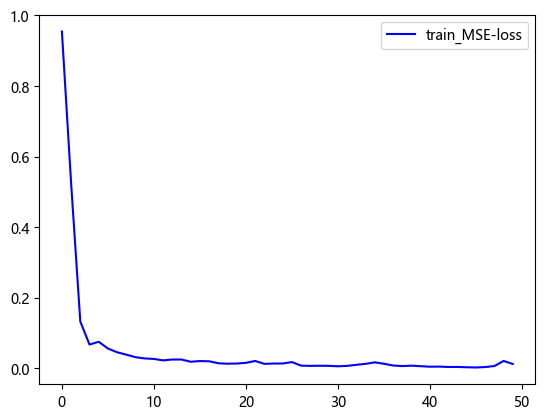

min_MSE: 0.0023361629925937833


In [6]:
# 训练模型
import time
import torch.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rc("font", family='Microsoft YaHei')

def model_train(epochs, model, optimizer, loss_function, train_loader, device):
    model = model.to(device)

    # 最低MSE  
    minimum_mse = 1000.
    # 最佳模型
    best_model = model

    train_mse = []     # 记录在训练集上每个epoch的 MSE 指标的变化情况   平均值
  
    # 计算模型运行时间
    start_time = time.time()
    for epoch in range(epochs):
         # 训练
        model.train()
        train_mse_loss = []    #保存当前epoch的MSE loss和
        for seq, labels in train_loader: 
            seq, labels = seq.to(device), labels.to(device)
            # 每次更新参数前都梯度归零和初始化
            optimizer.zero_grad()
            # 前向传播
            y_pred = model(seq)  #   torch.Size([16, 10])
            # 损失计算
            loss = loss_function(y_pred, labels)
            train_mse_loss.append(loss.item()) # 计算 MSE 损失
            # 反向传播和参数更新
            loss.backward()
            optimizer.step()
        #     break
        # break
        # 计算总损失
        train_av_mseloss = np.average(train_mse_loss) # 平均
        train_mse.append(train_av_mseloss)
        print(f'Epoch: {epoch+1:2} train_MSE-Loss: {train_av_mseloss:10.8f}')
       
        # 如果当前模型的 MSE 低于于之前的最佳准确率，则更新最佳模型
        #保存当前最优模型参数
        if train_av_mseloss < minimum_mse:
            minimum_mse = train_av_mseloss
            best_model = model# 更新最佳模型的参数
         
    # 保存最后的参数
    # torch.save(model.state_dict(), 'final_model_tcn.pt')
    # 保存最好的参数
    torch.save(best_model.state_dict(), 'best_model_tcn.pt')
    print(f'\nDuration: {time.time() - start_time:.0f} seconds')
    
    # 可视化
    plt.plot(range(epochs), train_mse, color = 'b',label = 'train_MSE-loss')
    plt.legend()
    plt.show()   #显示 lable 
    print(f'min_MSE: {minimum_mse}')

#  模型训练
epochs = 50
model_train(epochs, model, optimizer, loss_function, train_loader, device)

### 第一部分，训练集评估

In [7]:
# 模型预测
# 模型 测试集 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 加载模型的状态字典
model.load_state_dict(torch.load('best_model_tcn.pt'))
model = model.to(device)

# 预测数据
origin_data = []
pre_data = []
with torch.no_grad():
        for data, label in train_loader:
            # 原始标签
            origin_lable = label.tolist()
            origin_data += origin_lable
            model.eval()  # 将模型设置为评估模式
            
            # 预测
            data, label = data.to(device), label.to(device)
            train_pred = model(data)  # 对测试集进行预测
            train_pred = train_pred.tolist()
            pre_data += train_pred      

In [8]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# 反归一化处理
# 使用相同的均值和标准差对预测结果进行反归一化处理
# 反标准化
scaler  = load('../dataresult/scaler')
origin_data = scaler.inverse_transform(origin_data)
pre_data = scaler.inverse_transform(pre_data)

import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 模型分数
score = r2_score(origin_data, pre_data)
print('训练集上 模型分数-R^2:',score)

print('*'*50)
# 训练集上的预测误差
train_mse = mean_squared_error(origin_data, pre_data)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(origin_data, pre_data)
print('训练数据集上的均方误差-MSE: ',train_mse)
print('训练数据集上的均方根误差-RMSE: ',train_rmse)
print('训练数据集上的平均绝对误差-MAE: ',train_mae)

训练集上 模型分数-R^2: 0.9827259395355034
**************************************************
训练数据集上的均方误差-MSE:  0.0014193743120866232
训练数据集上的均方根误差-RMSE:  0.03767458443150532
训练数据集上的平均绝对误差-MAE:  0.026375423954349178


# 测试集评估

In [9]:
# 模型 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 加载模型的状态字典
model.load_state_dict(torch.load('best_model_tcn.pt'))
model = model.to(device)

# 预测数据
test_origin_data = []
test__pre_data = []
with torch.no_grad():
        for data, label in test_loader:
            # 原始标签
            origin_lable = label.tolist()
            test_origin_data += origin_lable
            model.eval()  # 将模型设置为评估模式
            
            # 预测
            data, label = data.to(device), label.to(device)
            pred = model(data)  # 对测试集进行预测
            pred = pred.tolist()
            test__pre_data += pred        

In [10]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# 反归一化处理
# 使用相同的均值和标准差对预测结果进行反归一化处理
# 反标准化
scaler  = load('../dataresult/scaler')
test_origin_data = scaler.inverse_transform(test_origin_data)
test__pre_data = scaler.inverse_transform(test__pre_data)

import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 模型分数
score = r2_score(test_origin_data, test__pre_data)
print('测试集上 模型分数-R^2:',score)

print('*'*50)
# 训练集上的预测误差
test_mse = mean_squared_error(test_origin_data, test__pre_data)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(test_origin_data, test__pre_data)
print('测试数据集上的均方误差-MSE: ',test_mse)
print('测试数据集上的均方根误差-RMSE: ',test_rmse)
print('测试数据集上的平均绝对误差-MAE: ',test_mae)

测试集上 模型分数-R^2: 0.9755632727781683
**************************************************
测试数据集上的均方误差-MSE:  0.00197006322627025
测试数据集上的均方根误差-RMSE:  0.03767458443150532
测试数据集上的平均绝对误差-MAE:  0.031081780234545563


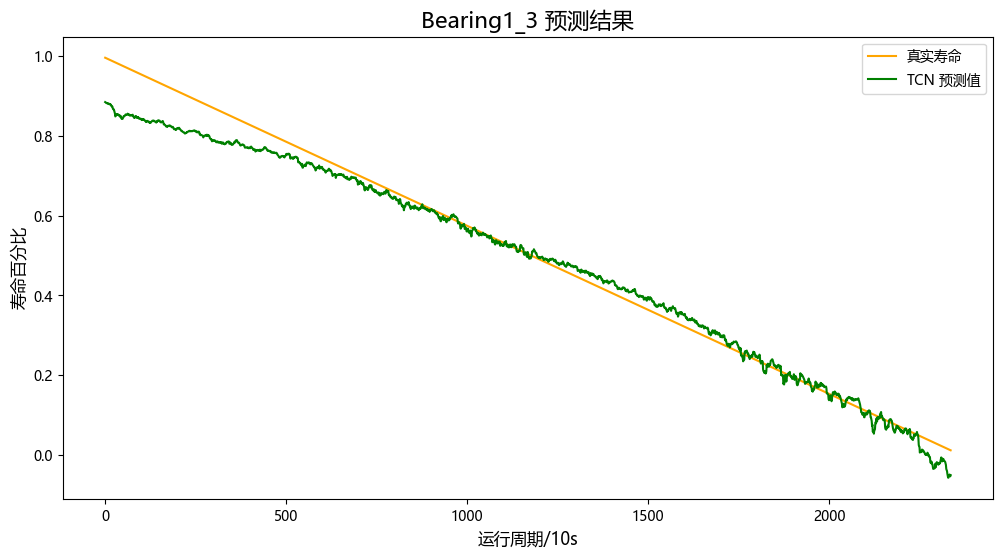

['../画图对比/tcn_pre']

In [11]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rc("font", family='Microsoft YaHei')

# 可视化结果
plt.figure(figsize=(12, 6), dpi=100)
plt.plot(test_origin_data, label='真实寿命',color='orange')  # 真实值
plt.plot(test__pre_data, label='TCN 预测值',color='green')  # 预测值

# plt.plot([-1,170],[2.0*0.7,2.0*0.7],c='black',lw=1,ls='--')  # 临界点直线  可自己调整位置

plt.xlabel('运行周期/10s', fontsize=12)
plt.ylabel('寿命百分比', fontsize=12)
plt.title('Bearing1_3 预测结果', fontsize=16)
plt.legend()
plt.show()

# 保存数据
# 保存数据
dump(test_origin_data, '../画图对比/tcn_origin') 
dump(test__pre_data, '../画图对比/tcn_pre') 